In [1]:
from ReadOutData import *
from Planewave_t import *
from cal_planewave import *
from NA import *
import matplotlib.pyplot as plt

In [2]:
# read data file
filename = 'ofd.out'
od = ReadOutData(filename)
od.readoutdata()
d = od.data

In [4]:
# extract complex field
de = d['cfield'][0] 
Ex = np.zeros((od.Ny, od.Nx), dtype=np.complex128)
Ey = np.zeros((od.Ny, od.Nx), dtype=np.complex128)
Ez = np.zeros((od.Ny, od.Nx), dtype=np.complex128)
for ix in range(15, 16):
    for iy in range(od.Ny):
        for iz in range(od.Nz):
            e, h = cal_planewave(od, ix, iy, iz)
            Ex[iy][iz] = complex(de['Ez_r'][NA(od, ix, iy, iz)], de['Ez_i'][NA(od, ix, iy, iz)]) + e[0]
            Ey[iy][iz] = complex(de['Ez_r'][NA(od, ix, iy, iz)], de['Ez_i'][NA(od, ix, iy, iz)]) + e[0]
            Ez[iy][iz] = complex(de['Ez_r'][NA(od, ix, iy, iz)], de['Ez_i'][NA(od, ix, iy, iz)]) + e[0]            
            

In [3]:
pwE = np.zeros((od.Ny, od.Nz), dtype=np.complex128)
pwH = np.zeros((od.Ny, od.Nz), dtype=np.complex128)
Ez = np.zeros((od.Ny, od.Nz), dtype=np.complex128)
H = np.zeros((od.Ny, od.Nz), dtype=np.complex128)
de = d['cfield'][0]

for ix in range(od.Nx):
    for iy in range(od.Ny):
        for iz in range(15, 16):
            e, h = cal_planewave(od, ix, iy, iz)
            pwE[ix][iy] = e[2]
            Ez[ix][iy] = complex(de['Ez_r'][NA(od, ix, iy, iz)], de['Ez_i'][NA(od, ix, iy, iz)])


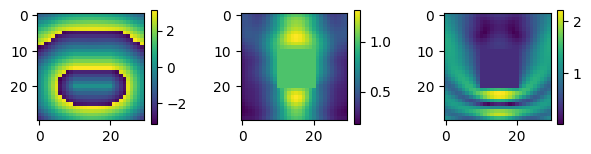

In [4]:
c = Ez
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(6, 6))
im1 = axes[0].imshow(np.angle(c))
fig.colorbar(im1, ax=axes[0], shrink=0.2)
im2 = axes[1].imshow(np.abs(c))
fig.colorbar(im2, ax=axes[1], shrink=0.2)
im3 = axes[2].imshow(np.abs(c+pwE))
fig.colorbar(im3, ax=axes[2], shrink=0.2)
plt.tight_layout()
plt.show()

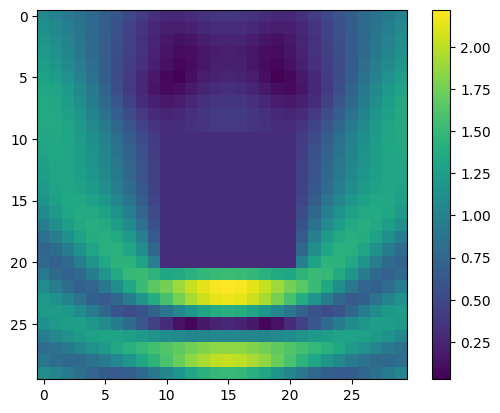

In [5]:
plt.imshow(np.abs(c+pwE))
plt.colorbar()

In [43]:
c = np.load("c.npy")

In [51]:
c3 = c[0:30, 0:30]

In [52]:
c3.shape

(30, 30)

In [22]:
od.Nj

33

In [23]:
de['Ez_r'].shape

(35937,)

In [24]:
33*33*33

35937

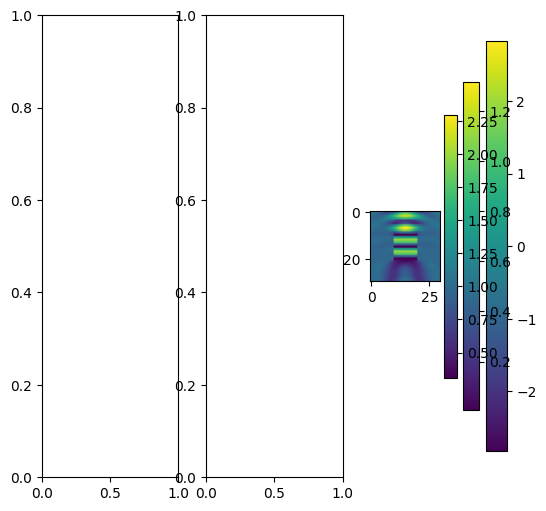

In [9]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(6, 6))
plt.imshow(np.angle(pwE))
plt.colorbar()
#plt.show()
plt.imshow(np.abs(Ez))
plt.colorbar()
#plt.show()
plt.imshow(np.abs(Ez+pwE))
plt.colorbar()
#plt.show()

In [22]:
od.Nz

30

In [57]:
pw = Planewave_t(od.data["Planewave"])


In [58]:
pw.r0

array([3.09773031e-01, 0.00000000e+00, 1.89681275e-17])

In [59]:
pw.ri

array([-1.000000e+00, -0.000000e+00, -6.123234e-17])

In [5]:
d = od.data

In [9]:
d['cfield'][0]['Ez_i']

array([0., 0., 0., ..., 0., 0., 0.], shape=(35937,), dtype=float32)

# 

In [16]:
np.abs(complex(1,1))

np.float64(1.4142135623730951)

In [54]:
!pwd


/home/shiro/sd-card/work/OpenFDTD_read_ofdFile
